# This notebook demonstrates how Text-to-Speech (TTS) works using the SpeechT5 model from Microsoft on Hugging Face.
Students will:
1 Convert text → speech using a pretrained Transformer model
2 Listen to the generated voice
3 Visualize the Mel spectrogram of the output speech

# Install Dependencies

In [ ]:
# Install all required libraries
# - transformers: for loading the pretrained SpeechT5 model
# - datasets: for sample voice embeddings
# - librosa + matplotlib: for audio visualization
# - soundfile: for saving audio output
# - torch: for running the model

!pip install torch librosa matplotlib soundfile transformers datasets --quiet


# Import Libraries

In [ ]:
# Import the necessary packages
import torch
import librosa, librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
from datasets import load_dataset
from IPython.display import Audio


# Load Model and Processor

In [ ]:
# ------------------------------------------------------------
# Text-to-Speech (TTS) Inference — Stage 1: Model Setup
# ------------------------------------------------------------
# This section loads the pretrained SpeechT5 components from Hugging Face.
# It includes:
# 1. Processor — handles text preprocessing (tokenization)
# 2. Model — maps text embeddings to speech representations
# 3. Vocoder — converts predicted speech tokens into real audio waveforms

from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
import torch, soundfile as sf
from IPython.display import Audio

# Load the pretrained models
processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts")
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")

# A vocoder (short for voice encoder/decoder) is the final stage of a TTS system.
# It transforms abstract sound features (like Mel spectrograms or speech tokens) into actual audio waveforms that we can play or store.



# Speaker Embedding and Text Preprocessing

In [ ]:
# ------------------------------------------------------------
# Stage 2: Speaker Embedding + Text Input
# ------------------------------------------------------------
# The model also needs a "speaker embedding" — a numeric representation of voice style.
# Normally, this embedding is generated by a Speaker Encoder model from a reference audio sample.
# Here we simulate it with a random 512-dimensional vector for a neutral synthetic voice.

speaker_embedding = torch.randn(1, 512)
print("Using a random speaker embedding (neutral synthetic voice).")

# Define the text that we want the AI to speak.
text = "Hello MS-ADS, welcome to your hands-on session on Text to Speech!"

# The processor converts text into model-readable token IDs.
inputs = processor(text=text, return_tensors="pt")
print("Text converted into token IDs:", inputs["input_ids"].shape)


Using a random speaker embedding (neutral synthetic voice).
Text converted into token IDs: torch.Size([1, 67])


# Generate, Decode, and Save Speech

In [ ]:
# ------------------------------------------------------------
# Stage 3: Inference — Text to Audio Generation
# ------------------------------------------------------------
# 1. The model generates a sequence of abstract "speech tokens" (latent audio features).
# 2. The vocoder converts those tokens into a real waveform (audio signal).
# 3. The waveform is saved and can be played back.

# Generate the final speech waveform using the SpeechT5 model and vocoder.
with torch.no_grad():
    speech_waveform = model.generate_speech(inputs["input_ids"], speaker_embedding, vocoder=vocoder)

# Save the generated waveform to a .wav file
sf.write("tts_output.wav", speech_waveform.numpy(), samplerate=16000)

# The samplerate=16000 parameter means the audio contains 16,000 air pressure
# measurements (samples) per second — standard for speech clarity and efficiency.
print("Speech generated and saved as 'tts_output.wav' (16 kHz).")

# Play the resulting audio
Audio("tts_output.wav")



Speech generated and saved as 'tts_output.wav' (16 kHz).


# Listen to the Generated Speech

In [ ]:
# Play the generated speech directly in the notebook
# The model converts text into realistic human-like voice

Audio("tts_output.wav")


# Visualize the Mel Spectrogram

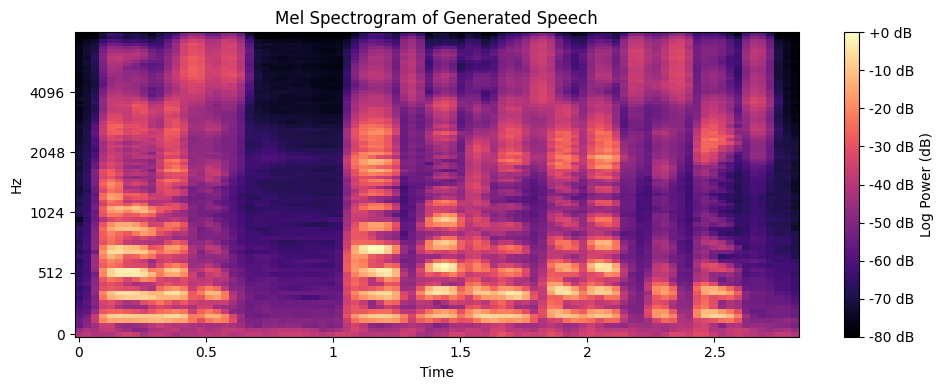

In [ ]:
# Load the generated audio file
import numpy as np

y, sr = librosa.load("tts_output.wav", sr=16000)

# Compute the Mel spectrogram
# ---------------------------------------------------------------
# A Mel spectrogram shows how energy (loudness) of each frequency
# changes over time — similar to what the model learns internally.
# ---------------------------------------------------------------
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80, fmax=8000)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

# Plot the Mel spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB', label="Log Power (dB)")
plt.title("Mel Spectrogram of Generated Speech")
plt.tight_layout()
plt.show()


In [ ]:
#This plot shows how the energy of sound changes across time (x-axis) and frequency (y-axis).

#X-axis: Time — how the sound evolves as the speech unfolds.#

#Y-axis: Frequency (Hz) — how high or low the sound is.

#Color intensity: Loudness (power in dB) — bright = stronger sound, dark = quieter.